In [1]:
import os
from pyhere import here

project_dir = here(".")
os.chdir(project_dir)

print(os.getcwd())


/Users/work/Data Science/sheffield-bats


In [2]:
%load_ext autoreload
%autoreload 2

import json

import elapid as ela
import geopandas as gpd
import rioxarray as rxr

from sklearn.metrics import roc_auc_score
from folium import Map, GeoJson, CircleMarker
from matplotlib import pyplot as plt


from sdm.models.utils.utils import prepare_occurrence_data
from sdm.models.maxent.maxent_model import evaluate_and_train_maxent_model
from sdm.raster.io import load_environmental_variables
from sdm.raster.utils import generate_point_grid
from sdm.occurrence.species_data import latin_name, activity_type, genus
from sdm.utils.io import load_config
from sdm.utils.io import load_boundary, load_model_config

from pathlib import Path

In [3]:
# load the config
config = load_config()
config


{'paths': {'raw_data': 'data/raw',
  'processed_data': 'data/processed',
  'models': 'data/sdm_models',
  'tuning_dir': 'data/sdm_tuning',
  'config_dir': 'data/sdm_config',
  'predictions': 'data/sdm_predictions',
  'model_config': 'model_config.yml',
  'variables_config': 'variables_config.yml',
  'occurence_data': 'data/processed/bats-tidy.geojson',
  'background_points': 'data/processed/background-points.geojson',
  'boundary': 'data/processed/boundary.geojson',
  'grid_points': 'data/evs/grid-points.parquet',
  'evs': 'data/processed/evs',
  'ev_tiff': 'data/evs/evs-to-model.tif'},
 'spatial': {'top': 646900,
  'left': 313000,
  'crs': 'EPSG:27700',
  'resolution': 100,
  'study_area_buffer': 7000},
 'crs': 'EPSG:27700',
 'mlflow': {'tracking_uri': 'sqlite:///mlflow.db',
  'experiment_name': 'species_sdm_experiment'}}

In [4]:
import topojson as tp

boundary = load_boundary(
    filepath=config["paths"]["boundary"], buffer_distance=0, target_crs=27700
)

# simplify the boundary to regions to make the calculation faster
boundary_tp = tp.Topology(boundary, prequantize=True)
boundary_tp.toposimplify(100, inplace=True)
boundary = boundary_tp.to_gdf()
boundary["geometry"] = boundary.geometry.make_valid()
boundary["geometry"] = boundary.geometry.buffer(0)


boundary_4326 = boundary.to_crs(4326)
boundary_4326

,geometry,County
0,"MULTIPOLYGON (((-0.92927 53.77354, -0.93328 53...",East Riding of Yorkshire
1,"MULTIPOLYGON (((-0.78862 54.56019, -0.78826 54...",North Yorkshire
2,"POLYGON ((-1.82224 53.52109, -1.80427 53.537, ...",South Yorkshire
3,"POLYGON ((-1.82224 53.52109, -1.82714 53.52349...",West Yorkshire


# Environmental Variables

In [5]:
evs_to_model, ev_path = load_environmental_variables(config["paths"]["ev_tiff"])

all_env_var_names = list(evs_to_model.data_vars.keys())
evs_to_model

<xarray.Dataset> Size: 918MB
Dimensions:                                   (x: 1930, y: 1544)
Coordinates:
  * x                                         (x) float64 15kB 3.562e+05 ... ...
  * y                                         (y) float64 12kB 3.716e+05 ... ...
    spatial_ref                               int64 8B 0
Data variables: (12/77)
    climate_stats_temp_ann_var                (y, x) float32 12MB ...
    climate_bioclim_bio_4                     (y, x) float32 12MB ...
    climate_bioclim_bio_7                     (y, x) float32 12MB ...
    climate_bioclim_bio_2                     (y, x) float32 12MB ...
    climate_stats_prec_ann_var                (y, x) float32 12MB ...
    terrain_dtm                               (y, x) float32 12MB ...
    ...                                        ...
    vom_vegetation_height_mean_1500m          (y, x) float32 12MB ...
    ceh_landcover_suburban_1500m              (y, x) float32 12MB ...
    os_cover_water_1500m                      (y, x) float32 12MB ...
    ceh_landcover_coniferous_woodland_1500m   (y, x) float32 12MB ...
    ceh_landcover_urban_1500m                 (y, x) float32 12MB ...
    ceh_landcover_improved_grassland_1500m    (y, x) float32 12MB ...
Attributes:
    AREA_OR_POINT:  Area

In [6]:
## Convert the env vars to a dataframe to make it easy to join with occurence

ev_df = evs_to_model.to_dataframe()
ev_df.reset_index(inplace=True)
ev_gdf = gpd.GeoDataFrame(ev_df, geometry=gpd.points_from_xy(ev_df.x, ev_df.y))
ev_gdf.crs = evs_to_model.rio.crs
ev_gdf = ev_gdf.drop(columns=["spatial_ref"])
ev_gdf.rename(columns={"x": "grid_x", "y": "grid_y"}, inplace=True)

# Drop rows with missing values - can't be used for modelling
# TODO: interpolate missing values
ev_gdf.dropna(inplace=True)

ev_gdf.head()


,grid_x,grid_y,climate_stats_temp_ann_var,climate_bioclim_bio_4,climate_bioclim_bio_7,climate_bioclim_bio_2,climate_stats_prec_ann_var,terrain_dtm,climate_stats_prec_ann_avg,climate_stats_temp_ann_avg,...,vom_vegetation_height_max_1500m,vom_vegetation_height_std_1500m,ceh_landcover_broadleaved_woodland_1500m,vom_vegetation_height_mean_1500m,ceh_landcover_suburban_1500m,os_cover_water_1500m,ceh_landcover_coniferous_woodland_1500m,ceh_landcover_urban_1500m,ceh_landcover_improved_grassland_1500m,geometry
25691,357850.0,470350.0,4.166143,436.094513,17.922857,6.568089,25.374966,32.633919,105.333336,9.004094,...,8.504331,1.850352,929.000000,0.980535,175.666672,2.926667,17.000000,54.777779,7506.222168,POINT (357850 470350)
25692,357850.0,470450.0,4.165142,435.929230,17.912872,6.566302,25.374966,34.947315,105.333336,8.998239,...,8.447737,1.831626,894.444458,0.954079,183.111115,2.957778,16.777779,55.333332,7586.000000,POINT (357850 470450)
25693,357850.0,470550.0,4.164124,435.769379,17.903704,6.564719,25.374966,36.411514,105.333336,8.992547,...,8.402530,1.812110,868.333313,0.928953,178.555557,3.041111,16.777779,49.888889,7624.333496,POINT (357850 470550)
25694,357850.0,470650.0,4.162974,435.644836,17.900000,6.564537,25.656248,37.293659,105.583336,8.988072,...,8.459895,1.820032,862.000000,0.926465,177.555557,3.122222,15.777778,44.444443,7648.111328,POINT (357850 470650)
25695,357850.0,470750.0,4.161742,435.544098,17.900000,6.565303,25.615751,40.439396,106.000000,8.984433,...,8.563900,1.846067,853.666687,0.933607,182.222229,3.153333,15.555555,45.222221,7720.888672,POINT (357850 470750)


# Load the Occurence

In [7]:
# load the occurrence data
bat_records = gpd.read_file(config["paths"]["occurence_data"])
bat_records = bat_records[bat_records.accuracy <= 100]


from leafmap.deckgl import Map

map_center = boundary_4326.union_all().centroid
m = Map(center=(map_center.y, map_center.x), zoom=7)

m.add_gdf(
    boundary,
    zoom_to_layer=False,
    get_fill_color=[60, 60, 60, 40],
)

m.add_gdf(
    bat_records,
    zoom_to_layer=False,
    get_radius=500,
    # pink
    get_fill_color=[255, 192, 203, 180],
)

m


Map(custom_attribution='', layers=(SolidPolygonLayer(get_fill_color=[60, 60, 60, 40], table=arro3.core.Table
+…

# Pick Species


In [8]:
from enum import StrEnum


class ActivityType(StrEnum):
    ROOST = "Roost"
    IN_FLIGHT = "In flight"


class LatinName(StrEnum):
    MYOBRA = "Myotis brandtii"
    MYOMYS = "Myotis mystacinus"
    MYODAU = "Myotis daubentonii"
    MYONAT = "Myotis nattereri"
    PIPPYG = "Pipistrellus pygmaeus"
    PIPNAT = "Pipistrellus nathusii"
    PIPPIP = "Pipistrellus pipistrellus"
    NYCNOC = "Nyctalus noctula"
    NYCLEI = "Nyctalus leisleri"
    PLEAUR = "Plecotus auritus"

In [137]:
latin_name = LatinName.MYOMYS
activity_type = ActivityType.IN_FLIGHT

# Generate Data

In [138]:
modelling_config = load_model_config("model_config.yml")

modelling_config

ModelConfig(maxent=MaxentConfigModel(feature_types=['linear', 'hinge'], beta_multiplier=3.0, beta_lqp=1.0, beta_hinge=1.0, beta_threshold=1.0, beta_categorical=1.0, n_hinge_features=10, n_threshold_features=10, clamp=True, convergence_tolerance=1e-05, use_lambdas='best', n_lambdas=100, class_weights='balanced', tau=0.5, transform='cloglog'), sampling=SamplingConfig(min_presence=15, subset_occurrence=None, subset_background=False, order_by_density_for_subset=True, sample_weight_n_neighbors=5, background=SamplingBackgroundConfig(factor=10, min_bg=1000, max_bg=10000), grid_size_m=2000.0), background=BackgroundConfig(n_background_points=8000, background_value=0.025, sigma=6.5, background_method=<BackgroundMethod.CONTRAST: 'contrast'>, transform_method=<TransformMethod.PRESENCE: 'presence'>))

<Axes: >

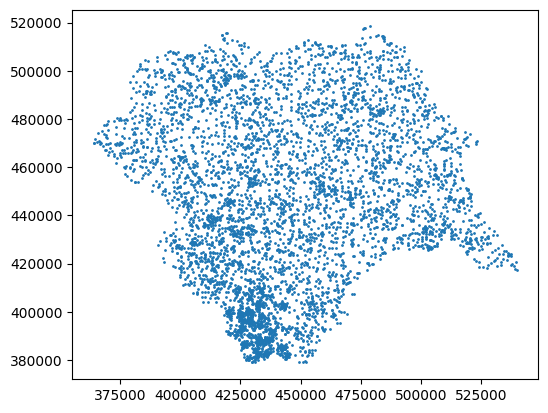

In [139]:
from sdm.occurrence.sampling import (
    generate_background_points_from_data,
    BackgroundMethod,
    TransformMethod,
)

bg_config = modelling_config.background


# genrate the background points
background_points, density_array = generate_background_points_from_data(
    occurrence_data=bat_records,  # [bat_records.activity_type == activity_type],
    boundary=boundary,
    n_background_points=bg_config.n_background_points,
    background_method=bg_config.background_method,
    background_value=bg_config.background_value,
    sigma=bg_config.sigma,
    transform_method=bg_config.transform_method,
    # region_weighting_factor=0.5,
    clip_to_boundary=True,
)

background_points.rename(columns={"presence": "class"}, inplace=True)

background_points.plot(
    markersize=1,
)

In [140]:
# use leafmap foliumap to plot the map
from leafmap.foliumap import Map
from folium import GeoJson, CircleMarker


centroid = boundary_4326.union_all().centroid
m = Map(location=[centroid.y, centroid.x], zoom_start=8, tiles="CartoDB positron")

# Add boundary
GeoJson(
    boundary, style_function=lambda x: {"fillColor": "none", "color": "black"}
).add_to(m)


# Add background points
GeoJson(
    background_points,
    style_function=lambda x: {
        "fillColor": "green",
        "color": "green",
        "radius": 3,
        "fillOpacity": 1,
        "weight": 0.5,
    },
    marker=CircleMarker(radius=3),
).add_to(m)

# Add bats points
GeoJson(
    bat_records[["geometry"]],
    style_function=lambda x: {
        "color": "orange",
        "fillColor": "orange",
        "radius": 3,
        "weight": 0.5,
        "fillOpacity": 1,
    },
    marker=CircleMarker(radius=3),
).add_to(m)

m


## Prepare Training Data

In [141]:
split_keys = ["latin_name", "activity_type"]

bat_records = bat_records[split_keys + ["geometry"]]
bat_records["class"] = 1
bat_records[split_keys].value_counts().to_frame()


count
latin_name                activity_type       
Pipistrellus pipistrellus Roost           4075
                          In flight       3258
Plecotus auritus          Roost           1548
Pipistrellus pygmaeus     Roost           1067
Myotis nattereri          Roost            707
Pipistrellus pygmaeus     In flight        602
Nyctalus noctula          In flight        559
Myotis daubentonii        In flight        441
                          Roost            424
Nyctalus noctula          Roost            273
Myotis mystacinus         Roost            249
Plecotus auritus          In flight        225
Nyctalus leisleri         In flight        172
Myotis nattereri          In flight         72
Nyctalus leisleri         Roost             50
Myotis brandtii           Roost             47
Myotis mystacinus         In flight         39
Pipistrellus nathusii     Roost             32
                          In flight         15
Myotis brandtii           In flight         13
Eptesicus serotinus       In flight          4
Vespertilio murinus       In flight          1

In [142]:
## Annotate the points with the environmental variables
resolution = evs_to_model.rio.resolution()
tolerance = abs(resolution[0])

occurence_data = gpd.sjoin_nearest(
    bat_records, ev_gdf, how="inner", max_distance=tolerance
)
background_data = gpd.sjoin_nearest(
    background_points, ev_gdf, how="inner", max_distance=tolerance
)

occurence_data.drop(columns=["index_right"], inplace=True)
background_data.drop(columns=["index_right"], inplace=True)

occurence_data.head()


,latin_name,activity_type,geometry,class,grid_x,grid_y,climate_stats_temp_ann_var,climate_bioclim_bio_4,climate_bioclim_bio_7,climate_bioclim_bio_2,...,ceh_landcover_arable_1500m,vom_vegetation_height_max_1500m,vom_vegetation_height_std_1500m,ceh_landcover_broadleaved_woodland_1500m,vom_vegetation_height_mean_1500m,ceh_landcover_suburban_1500m,os_cover_water_1500m,ceh_landcover_coniferous_woodland_1500m,ceh_landcover_urban_1500m,ceh_landcover_improved_grassland_1500m
0,Nyctalus noctula,In flight,POINT (465350 457750),1,465350.0,457750.0,4.370765,457.289093,19.998690,7.670608,...,2233.444336,9.595185,2.277521,1001.111084,1.572917,398.333344,3.298889,255.888885,144.777771,5373.888672
1,Nyctalus noctula,In flight,POINT (429550 477250),1,429550.0,477250.0,4.276229,447.886993,19.274574,7.206034,...,4777.444336,10.218222,2.400440,1222.777832,1.511334,240.111115,6.936666,25.222221,119.888885,3014.111084
2,Nyctalus noctula,In flight,POINT (446450 435450),1,446450.0,435450.0,4.431757,461.542175,20.190638,7.692239,...,7587.777832,5.131075,1.140973,1044.222168,0.602043,164.777771,0.950000,3.111111,43.000000,1135.444458
3,Nyctalus noctula,In flight,POINT (439650 467050),1,439650.0,467050.0,4.357553,455.122711,19.600000,7.385443,...,4730.888672,8.706750,1.794124,226.777771,0.793321,1622.777832,2.302222,23.555555,734.555542,2476.888916
4,Nyctalus noctula,In flight,POINT (429550 477250),1,429550.0,477250.0,4.276229,447.886993,19.274574,7.206034,...,4777.444336,10.218222,2.400440,1222.777832,1.511334,240.111115,6.936666,25.222221,119.888885,3014.111084


In [143]:
background_data.head()

,geometry,class,density,grid_x,grid_y,climate_stats_temp_ann_var,climate_bioclim_bio_4,climate_bioclim_bio_7,climate_bioclim_bio_2,climate_stats_prec_ann_var,...,ceh_landcover_arable_1500m,vom_vegetation_height_max_1500m,vom_vegetation_height_std_1500m,ceh_landcover_broadleaved_woodland_1500m,vom_vegetation_height_mean_1500m,ceh_landcover_suburban_1500m,os_cover_water_1500m,ceh_landcover_coniferous_woodland_1500m,ceh_landcover_urban_1500m,ceh_landcover_improved_grassland_1500m
0,POINT (514441.203 442453.071),0,5.423015e-07,514450.0,442450.0,4.441024,463.906311,19.500000,6.968954,6.898067,...,6706.333496,5.357224,1.272700,825.333313,1.092024,88.888885,1.828889,5.777778,20.666666,2296.333252
1,POINT (422841.203 472053.071),0,3.505855e-07,422850.0,472050.0,4.173055,436.872681,18.677868,6.904690,11.820415,...,52.000000,11.879468,2.775306,716.111084,1.955739,170.000000,3.840000,516.888916,28.333334,8048.333496
2,POINT (422441.203 390553.071),0,2.036014e-06,422450.0,390550.0,4.345515,454.397736,18.785065,6.659104,17.556852,...,1.111111,8.939491,2.150255,533.555542,2.753365,31.555555,5.957778,1455.111084,0.000000,604.555542
3,POINT (418341.203 512753.071),0,2.933409e-07,418350.0,512750.0,4.090966,427.902069,18.512728,7.143146,7.847063,...,5266.111328,6.872002,1.442162,490.444458,0.828293,260.333344,1.695556,0.000000,42.000000,3879.222168
5,POINT (433341.203 389253.071),0,2.948036e-06,433350.0,389250.0,4.397895,459.043945,19.782988,7.298817,13.651160,...,67.111115,11.573940,2.312955,862.444458,1.101887,4663.111328,1.701111,11.888889,2645.444336,1581.777832


In [144]:
def get_presence_data(
    presence: gpd.GeoDataFrame,
    latin_name: str,
    activity_type: str,
):
    chunk = presence[
        (presence.activity_type == activity_type) & (presence.latin_name == latin_name)
    ]
    return chunk


def drop_duplicates(
    gdf: gpd.GeoDataFrame,
    index_cols=["grid_x", "grid_y"],
):
    gdf = gdf.drop_duplicates(subset=index_cols)
    return gdf


activity_type = activity_type

species_presence = get_presence_data(
    occurence_data,
    latin_name,
    activity_type,
)

species_presence = drop_duplicates(species_presence)

species_presence.head()


,latin_name,activity_type,geometry,class,grid_x,grid_y,climate_stats_temp_ann_var,climate_bioclim_bio_4,climate_bioclim_bio_7,climate_bioclim_bio_2,...,ceh_landcover_arable_1500m,vom_vegetation_height_max_1500m,vom_vegetation_height_std_1500m,ceh_landcover_broadleaved_woodland_1500m,vom_vegetation_height_mean_1500m,ceh_landcover_suburban_1500m,os_cover_water_1500m,ceh_landcover_coniferous_woodland_1500m,ceh_landcover_urban_1500m,ceh_landcover_improved_grassland_1500m
716,Myotis mystacinus,In flight,POINT (397250 433250),1,397250.0,433250.0,4.176686,437.627441,17.795691,6.266757,...,10.444445,0.444521,0.087315,4.888889,0.040732,4.000000,8.053333,85.555557,1.000000,253.333328
717,Myotis mystacinus,In flight,POINT (438179.5 445439.5),1,438150.0,445450.0,4.386285,458.897003,19.877762,7.409957,...,3632.444336,9.426626,2.018732,673.777771,0.994120,1545.333374,2.018889,1.333333,128.555557,3848.333252
718,Myotis mystacinus,In flight,POINT (432810.5 413160.5),1,432850.0,413150.0,4.404741,459.279785,19.699774,7.287070,...,5772.333496,10.308255,2.564291,1568.888916,2.205780,381.222229,1.278889,70.666664,91.444443,2058.444336
719,Myotis mystacinus,In flight,POINT (417550 420350),1,417550.0,420350.0,4.373794,456.987976,19.199137,6.903432,...,843.555542,5.805126,0.892279,1507.111084,0.230782,2160.666748,3.365556,12.777778,824.222229,4360.333496
720,Myotis mystacinus,In flight,POINT (404397.5 420310.5),1,404350.0,420350.0,4.240511,442.335175,18.177038,6.383809,...,73.777779,8.255920,1.487202,1153.888916,0.542448,1450.222168,1.327778,21.111111,177.666672,6336.888672


In [145]:
from typing import List, Optional


def grid_sample(
    gdf: gpd.GeoDataFrame,
    stratify_cols: Optional[List[str]] = None,
    grid_size_x: float = 100,
    grid_size_y: float = 100,
) -> gpd.GeoDataFrame:
    """
    Get a sample of points stratified by the stratify_cols so there is
    one point per grid cell per stratify_cols group
    """
    gdf = gdf.copy()
    centroids = gdf.geometry.centroid

    x_bins = (centroids.x // grid_size_x).astype(int)
    y_bins = (centroids.y // grid_size_y).astype(int)

    gdf["_x_bin"] = x_bins
    gdf["_y_bin"] = y_bins

    if stratify_cols is None:
        stratify_cols = []

    gdf = gdf.groupby(stratify_cols + ["_x_bin", "_y_bin"]).apply(
        lambda x: x.sample(1, random_state=42)
    )
    gdf.drop(columns=["_x_bin", "_y_bin"], inplace=True)
    return gdf


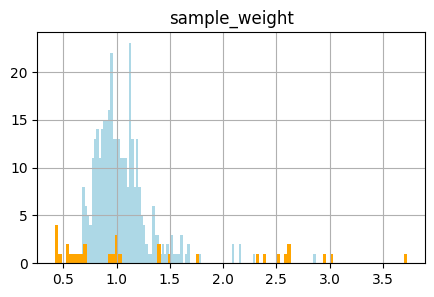

In [146]:
from shapely import distance
import numpy as np


def get_distance_matrix(
    a: gpd.GeoSeries,
    b: gpd.GeoSeries,
):
    A = a.array.to_numpy()
    B = b.array.to_numpy()

    dist_mat = distance(A[:, None], B[None, :])
    return dist_mat


dmax_by_species_m = {
    "Pipistrellus pipistrellus": 3000,  # very common, short-range forager
    "Pipistrellus pygmaeus": 3000,
    "Pipistrellus nathusii": 4000,  # more mobile pipistrelle
    "Plecotus auritus": 3000,  # typical 2–3 km range
    "Myotis daubentonii": 3000,  # riparian, but rarely >3 km from water/roost
    "Myotis nattereri": 3500,
    "Myotis mystacinus": 3000,
    "Myotis brandtii": 3000,
    "Nyctalus noctula": 6000,  # big, fast, wide-ranging
    "Nyctalus leisleri": 6000,
    "Eptesicus serotinus": 6000,  # similar movement ecology to Nyctalus
    "Vespertilio murinus": 7000,  # most mobile of the group
}

sort_density = False
limit_to_range = True
grid_size_m = modelling_config.sampling.grid_size_m


d_min = 500
d_max = np.Inf  # dmax_by_species_m[latin_name]

p_dist = get_distance_matrix(
    species_presence.geometry,
    background_data.geometry,
).min(axis=0)

n_max = len(species_presence) * 10

if limit_to_range:
    # get background points within the distance range
    species_absence = background_data[(p_dist >= d_min) & (p_dist <= d_max)]
else:
    species_absence = background_data

species_absence = drop_duplicates(species_absence)


species_presence = grid_sample(
    species_presence,
    grid_size_x=grid_size_m,
    grid_size_y=grid_size_m,
)

species_absence = grid_sample(
    species_absence,
    grid_size_x=grid_size_m,
    grid_size_y=grid_size_m,
)


if sort_density:
    species_absence = species_absence.sort_values(
        by="density",
        ascending=False,
    ).head(n_max)
else:
    species_absence = species_absence.sample(
        n=min(len(species_absence), n_max), replace=False, random_state=42
    )


# get the sample weights
species_presence["sample_weight"] = ela.distance_weights(
    species_presence.geometry,
    n_neighbors=10,
)
species_absence["sample_weight"] = ela.distance_weights(
    species_absence.geometry,
    n_neighbors=10,
)
fig, ax = plt.subplots(figsize=(5, 3))
species_absence.hist(
    column="sample_weight",
    bins=100,
    ax=ax,
    color="lightblue",
)
species_presence.hist(
    column="sample_weight",
    bins=100,
    ax=ax,
    color="orange",
)

plt.show()


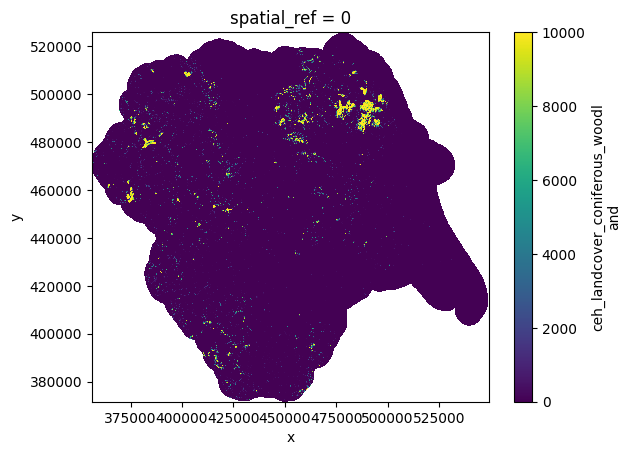

In [147]:
evs_to_model["ceh_landcover_coniferous_woodland"].plot()

In [148]:
from leafmap.deckgl import Map as DeckMap


map_center = boundary_4326.union_all().centroid
m = DeckMap(center=(map_center.y, map_center.x), zoom=7)

m.add_gdf(
    boundary,
    zoom_to_layer=False,
    get_fill_color=[60, 60, 60, 30],
)
point_radius = 250

m.add_gdf(
    species_absence,
    zoom_to_layer=False,
    # black
    get_fill_color=[0, 0, 0, 180],
    get_radius=point_radius,
)
m.add_gdf(
    species_presence,
    zoom_to_layer=False,
    get_radius=point_radius,
    # orange
    get_fill_color=[255, 165, 0, 180],
)

print(
    f"There are {len(species_presence)} presence points and {len(species_absence)} background points for {latin_name} - {activity_type}"
)
m


There are 32 presence points and 350 background points for Myotis mystacinus - In flight


Map(custom_attribution='', layers=(SolidPolygonLayer(get_fill_color=[60, 60, 60, 30], table=arro3.core.Table
+…

In [149]:
from typing import Any


import pandas as pd

species_data = pd.concat([species_presence, species_absence])
columns = [
    "class",
    "sample_weight",
    "geometry",
] + list(evs_to_model.data_vars.keys())
species_data = species_data[columns]
species_data.head()

,,,class,sample_weight,geometry,climate_stats_temp_ann_var,climate_bioclim_bio_4,climate_bioclim_bio_7,climate_bioclim_bio_2,climate_stats_prec_ann_var,terrain_dtm,climate_stats_prec_ann_avg,...,ceh_landcover_arable_1500m,vom_vegetation_height_max_1500m,vom_vegetation_height_std_1500m,ceh_landcover_broadleaved_woodland_1500m,vom_vegetation_height_mean_1500m,ceh_landcover_suburban_1500m,os_cover_water_1500m,ceh_landcover_coniferous_woodland_1500m,ceh_landcover_urban_1500m,ceh_landcover_improved_grassland_1500m
_x_bin,_y_bin,,,,,,,,,,,,,,,,,,,,,,
198,216,716,1,2.405053,POINT (397250 433250),4.176686,437.627441,17.795691,6.266757,26.772057,384.185791,121.916664,...,10.444445,0.444521,0.087315,4.888889,0.040732,4.000000,8.053333,85.555557,1.000000,253.333328
202,210,720,1,1.749049,POINT (404397.5 420310.5),4.240511,442.335175,18.177038,6.383809,15.748677,120.729393,82.250000,...,73.777779,8.255920,1.487202,1153.888916,0.542448,1450.222168,1.327778,21.111111,177.666672,6336.888672
205,224,723,1,2.629380,POINT (410966.5 448531.5),4.235645,442.573090,18.496555,6.634681,13.234005,89.766594,75.166664,...,33.000000,12.780718,2.747805,1554.777832,1.450187,2536.777832,3.975556,49.666668,445.888885,5160.555664
207,201,3878,1,0.929681,POINT (415539.5 402498.5),4.320899,451.187347,18.282360,6.320854,20.357056,307.254364,100.083336,...,19.888889,1.856390,0.388187,81.555557,0.218971,138.222229,10.427778,234.111115,18.555555,506.444458
208,210,719,1,1.387719,POINT (417550 420350),4.373794,456.987976,19.199137,6.903432,10.941765,56.210487,64.333336,...,843.555542,5.805126,0.892279,1507.111084,0.230782,2160.666748,3.365556,12.777778,824.222229,4360.333496


In [150]:
import numpy as np
import pandas as pd
from typing import List


def get_covariance_matrix_long(
    df: pd.DataFrame, features: List[str], min_abs_cov: float = 0.5
) -> pd.DataFrame:
    """
    Returns a tidy DataFrame of pairwise covariance values (upper triangle, no diagonal)
    for a subset of features, sorted by absolute value and filtered by minimum absolute covariance.

    Parameters:
        df: pd.DataFrame
        features: List[str]
        min_abs_cov: float

    Returns:
        pd.DataFrame with columns ['index', 'variable', 'cov', 'abs_cov']
    """
    corr_matrix = df[features].corr(method="pearson").round(4)
    # Keep only upper triangle, exclude the diagonal
    corr_matrix = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    corr_matrix_long = corr_matrix.reset_index().melt(
        id_vars=["index"],
        value_vars=corr_matrix.columns,
        var_name="variable",
        value_name="corr",
    )
    corr_matrix_long = corr_matrix_long.dropna()
    corr_matrix_long["abs_corr"] = corr_matrix_long["corr"].abs()
    corr_matrix_long = corr_matrix_long.sort_values(by="abs_corr", ascending=False)
    return corr_matrix_long[corr_matrix_long["abs_corr"] > min_abs_cov]


from enum import Enum


class CovarianceAggregation(Enum):
    MEAN = "mean"
    MAX = "max"


def calculate_covariance_score(
    df: pd.DataFrame,
    columns: List[str] = None,
    agg: CovarianceAggregation = CovarianceAggregation.MEAN,
) -> float:
    if columns is None:
        columns = df.columns
    match agg:
        case CovarianceAggregation.MEAN:
            return df[columns].corr(method="pearson").abs().values.mean()
        case CovarianceAggregation.MAX:
            return df[columns].corr(method="pearson").abs().values.max()
        case _:
            raise ValueError(f"Invalid aggregation: {agg}")


# Modelling

In [151]:
path = Path("data/sdm_predictions/visualization/shap")

In [152]:
%autoreload 2
import mlflow
from sdm.models.maxent.maxent_model import (
    create_maxent_pipeline,
    get_feature_config,
    ActivityType,
    DefaultMaxentConfig,
)
import yaml

np.random.seed(42)

model_id = f"{latin_name}_{activity_type}"
config_dir = Path("data/sdm_config")

feature_config_path = config_dir / f"{model_id.replace(' ', '_')}/variables_config.yml"
model_config_path = config_dir / f"{model_id.replace(' ', '_')}/model_config.yml"

# Load the model config
with open(model_config_path, "r") as f:
    model_config = yaml.safe_load(f)

# Load the feature config
with open(feature_config_path, "r") as f:
    feature_config = yaml.safe_load(f)


model_features = feature_config["variables"]


maxent_model_config = DefaultMaxentConfig(**model_config["model"]["maxent"])

maxent_model = create_maxent_pipeline(
    feature_names=model_features,
    maxent_n_jobs=-1,
    model_config=maxent_model_config,
)
print(latin_name)
print(activity_type)


def to_percent(x):
    return (x * 100).round(1)


# Configure MLflow from project config so we use the same tracking store/experiment
tracking_uri = config["mlflow"]["tracking_uri"]
experiment_name = config["mlflow"]["experiment_name"]
mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment(experiment_name)


# with mlflow.start_run():|
final_model, cv_models, cv_scores = evaluate_and_train_maxent_model(
    model=maxent_model,
    occurrence_gdf=species_data,
    metric_fn=roc_auc_score,
    n_cv_folds=3,
)

cov_score = calculate_covariance_score(species_data[model_features]).round(2)


print(f"Mean AUC: {to_percent(cv_scores.mean())}%")
print(f"Variation: +/- {to_percent(cv_scores.std())}%")
print(f"Mean covariance score: {cov_score}")
maxent_model

Myotis mystacinus
In flight
Mean AUC: 83.2%
Variation: +/- 12.1%
Mean covariance score: 0.22


Pipeline(steps=[('feature_selection',
                 FeatureSubsetter(feature_names=['climate_stats_temp_ann_var',
                                                 'terrain_dtm',
                                                 'climate_stats_temp_mat_avg',
                                                 'os_distance_distance_to_buildings',
                                                 'climate_bioclim_bio_8',
                                                 'terrain_stats_slope',
                                                 'vom_vegetation_height_std',
                                                 'terrain_stats_tpi',
                                                 'os_cover_water',
                                                 'terrain_stats_twi',
                                                 'ceh_landcover_coniferous_woodland',
                                                 'os_di...
                                                 'vom_vegetation_height_max_500m',
                                                 'ceh_landcover_broadleaved_woodland_500m',
                                                 'os_cover_water_500m',
                                                 'ceh_landcover_urban_500m'])),
                ('scaling', StandardScaler()),
                ('maxent',
                 MaxentModel(beta_categorical=1.4, beta_hinge=4.3, beta_lqp=4.2,
                             beta_multiplier=10, beta_threshold=4.2,
                             class_weights='balanced',
                             feature_types=['linear', 'hinge'], n_cpus=-1,
                             n_hinge_features=18, n_threshold_features=0))])

This cell computes correlations between variables in the dataset. It is useful in determining where a varaible might be a proxy for another. If there is an important variable that doesn't make sense, then it could be acting as a proxy for another variable. Use this to find alternatives where the correlation is high.

You can also use it to find variables which aren't highly correlated and could be added to the model.

In [153]:
var = "ceh_landcover_wetland"

ev_gdf[all_env_var_names].sample(10_000).corr(method="pearson").abs().round(
    4
).reset_index().melt(
    id_vars=["index"],
    value_vars=ev_gdf[all_env_var_names].columns,
    var_name="variable",
    value_name="corr",
).sort_values(by="corr", ascending=False).query(f"index == '{var}'")


,index,variable,corr
702,ceh_landcover_wetland,ceh_landcover_wetland,1.0000
2935,ceh_landcover_wetland,ceh_landcover_wetland_500m,0.9366
3936,ceh_landcover_wetland,ceh_landcover_wetland_1000m,0.8866
4937,ceh_landcover_wetland,ceh_landcover_wetland_1500m,0.8475
394,ceh_landcover_wetland,terrain_dtm,0.5723
...,...,...,...
5707,ceh_landcover_wetland,ceh_landcover_coniferous_woodland_1500m,0.0089
2781,ceh_landcover_wetland,terrain_stats_aspect_northness_slope,0.0086
1241,ceh_landcover_wetland,ceh_landcover_grassland,0.0068
2242,ceh_landcover_wetland,terrain_stats_tpi,0.0062


<Axes: >

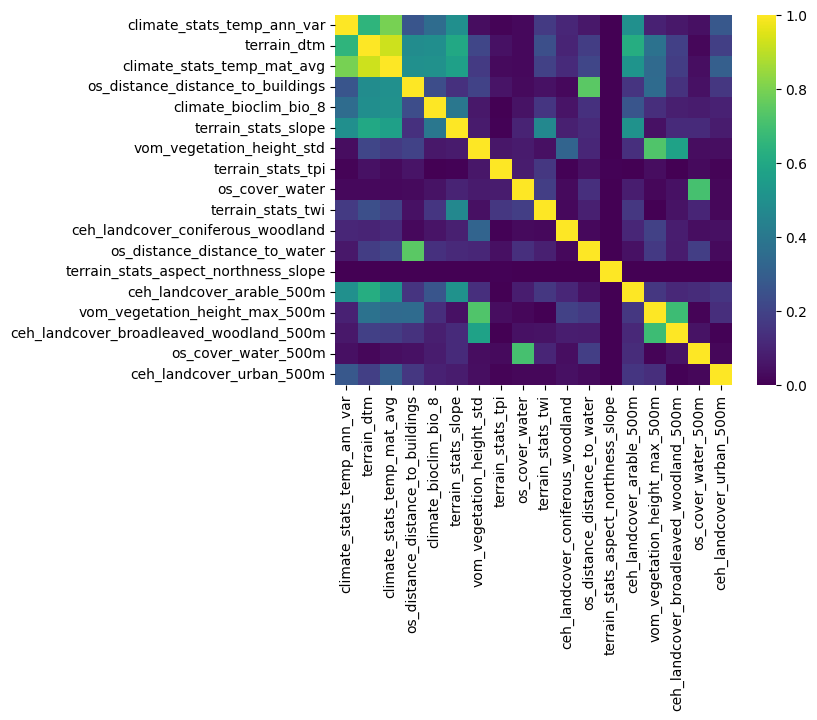

In [154]:
# Example usage:
get_covariance_matrix_long(species_data, model_features, min_abs_cov=0).head(10)

# plot a correlation matrix
import seaborn as sns

sns.heatmap(
    ev_gdf[model_features].corr(method="pearson").abs().round(4), cmap="viridis"
)


In [155]:
model_id = f"{latin_name}-{activity_type}"

In [156]:
from sdm.models.maxent.maxent_model import apply_models_to_raster

prediction_paths = []
# Define the arguments for each task

path_predict = Path(f"data/temp/prediction-{latin_name}-{activity_type}.tif")
path_predict.parent.mkdir(parents=True, exist_ok=True)

apply_models_to_raster(
    models={
        model_id: final_model,
    },
    raster_path=ev_path,
    output_path=str(path_predict),
    windowed=True,
    window_size=512,
)


Processing windows:   0%|                              | 0/16 [00:00<?, ?it/s]

In [157]:
from rasterio.mask import mask
import numpy as np
import rasterio as rio
import rioxarray as rxr

# mask the prediction raster with the boundary
predictions_masked = Path(
    f"data/temp/prediction-{latin_name}-{activity_type}-masked.tif"
)

predictions = rxr.open_rasterio(path_predict)
predictions = predictions.rio.clip(boundary.geometry)
predictions = predictions.rio.reproject(4326)
predictions.rio.to_raster(predictions_masked)

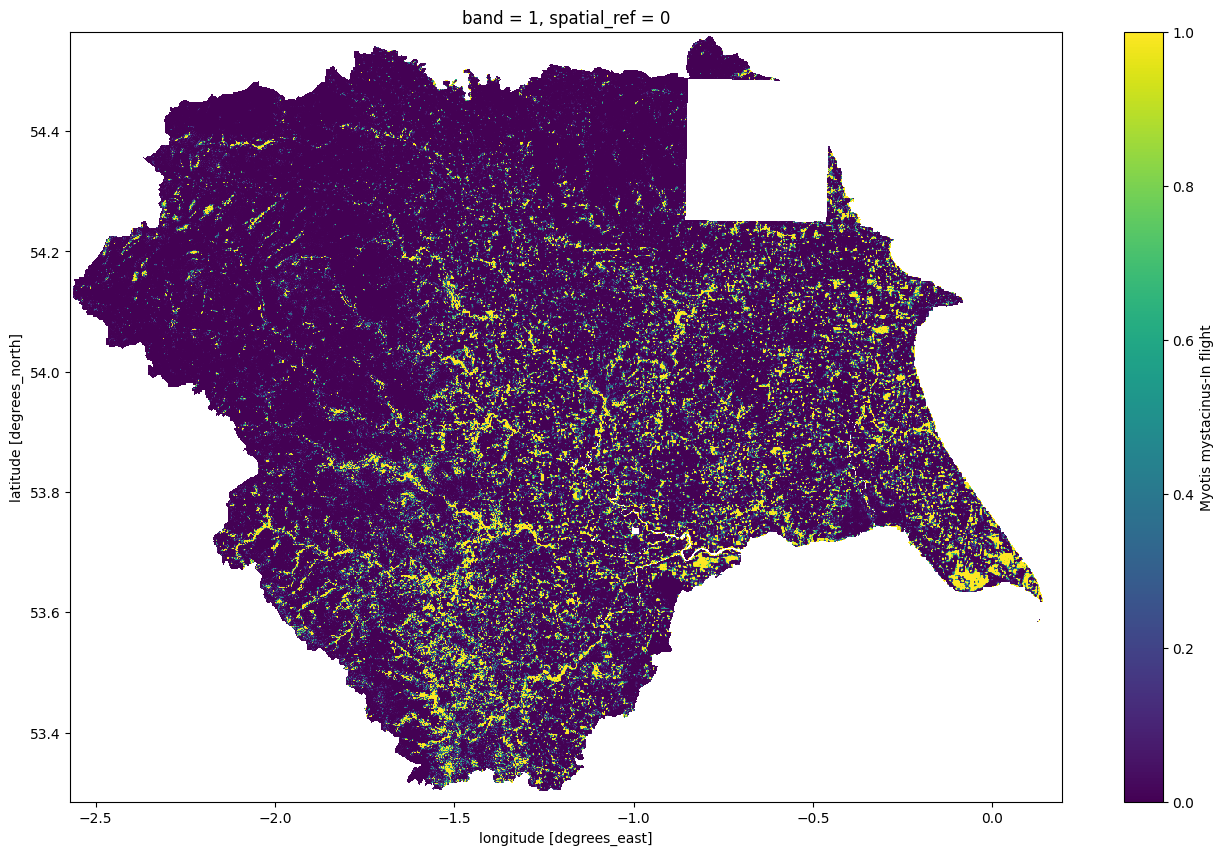

In [158]:
predictions.where(predictions > 0.0).plot(figsize=(16, 10))

PermutationExplainer explainer: 101it [00:20,  2.53it/s]                         


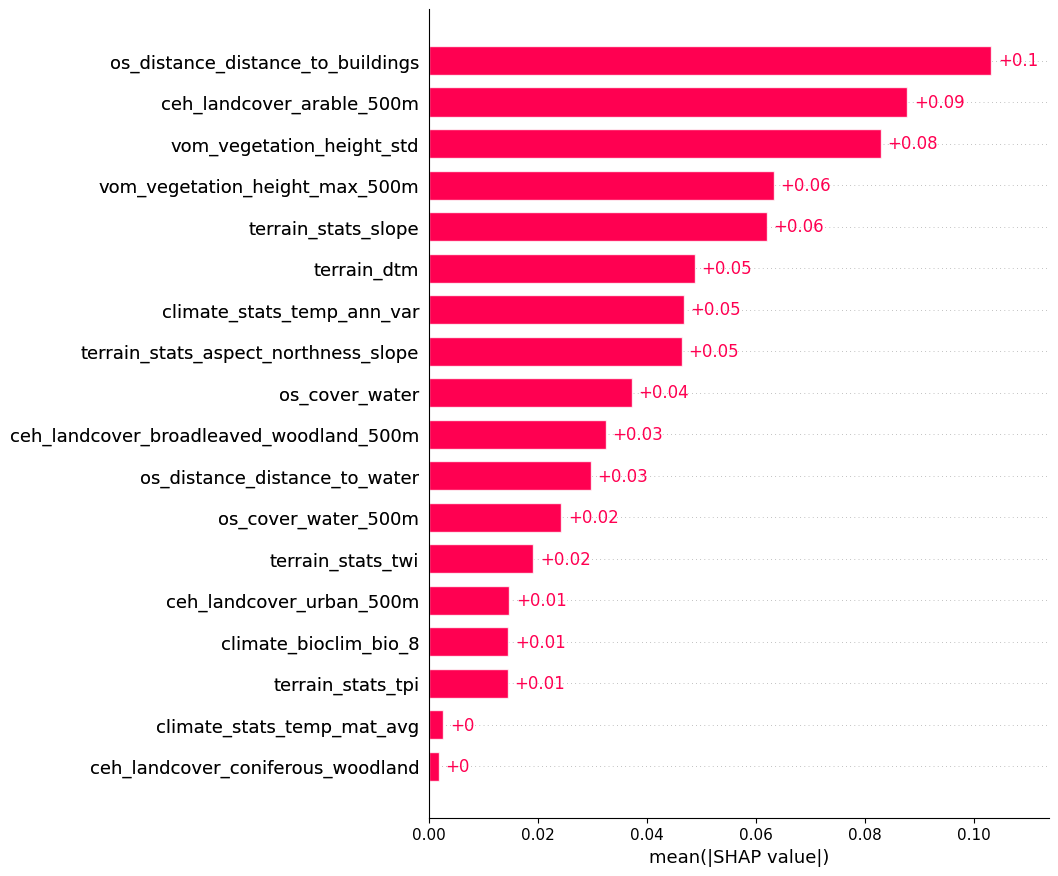

In [159]:
import numpy as np
import shap
import pandas as pd
from typing import Tuple, Optional


def compute_shap_for_pipeline(
    model,
    X: pd.DataFrame,
    feature_names,
    positive_class: int = 1,
    sample_size: int = 200,
    n_explain: Optional[int] = 200,
    random_state: int = 42,
) -> Tuple[shap.Explainer, shap._explanation.Explanation, pd.DataFrame]:
    """
    Compute SHAP values for a scikit-learn pipeline that supports predict_proba.

    Parameters
    ----------
    model
        Fitted sklearn Pipeline (or any estimator) with predict_proba.
    X
        DataFrame of input features (same structure as used for training).
    feature_names
        Sequence of feature names (columns of X, or subset/order used for model).
    positive_class
        Index of the positive class in predict_proba output.
    sample_size
        Number of background samples for the explainer.
    n_explain
        Number of rows to explain. If None, use all rows of X.
    random_state
        Seed for sampling.

    Returns
    -------
    explainer
        SHAP explainer object (can be reused).
    shap_values
        SHAP Explanation object for X_explain.
    X_explain
        DataFrame of rows that shap_values correspond to.
    """

    # Ensure we only use the requested features, in a consistent order
    X = X[list(feature_names)]

    # Background sample
    sample_size = min(sample_size, len(X))
    background = X.sample(n=sample_size, random_state=random_state)

    # Prediction function returning probability for positive class
    def predict_fn(data):
        proba = model.predict_proba(data)
        return proba[:, positive_class]

    explainer = shap.Explainer(
        predict_fn,
        background,
        algorithm="permutation",
        model_output="probability",
    )

    # Data to explain
    if n_explain is None:
        X_explain = X
    else:
        n_explain = min(n_explain, len(X))
        X_explain = X.sample(n=n_explain, random_state=random_state + 1)

    shap_values = explainer(X_explain)

    return explainer, shap_values, X_explain


explainer, shap_values, X_explain = compute_shap_for_pipeline(
    final_model,
    ev_gdf[model_features],
    feature_names=model_features,
    sample_size=1000,
    n_explain=100,
)


# shap_values from your explainer call (for the positive class)
values = shap_values.values  # (n_samples, n_features)

# Global importance
shap.plots.bar(shap_values, max_display=25)  # new API


In [160]:
variable_scores = pd.DataFrame(
    {
        "variable": model_features,
        "score": shap_values.values.mean(axis=0),
    },
)
variable_scores["score_abs"] = variable_scores["score"].abs()
variable_scores = variable_scores.sort_values(by="score_abs", ascending=False)
variable_scores.reset_index(drop=True, inplace=True)


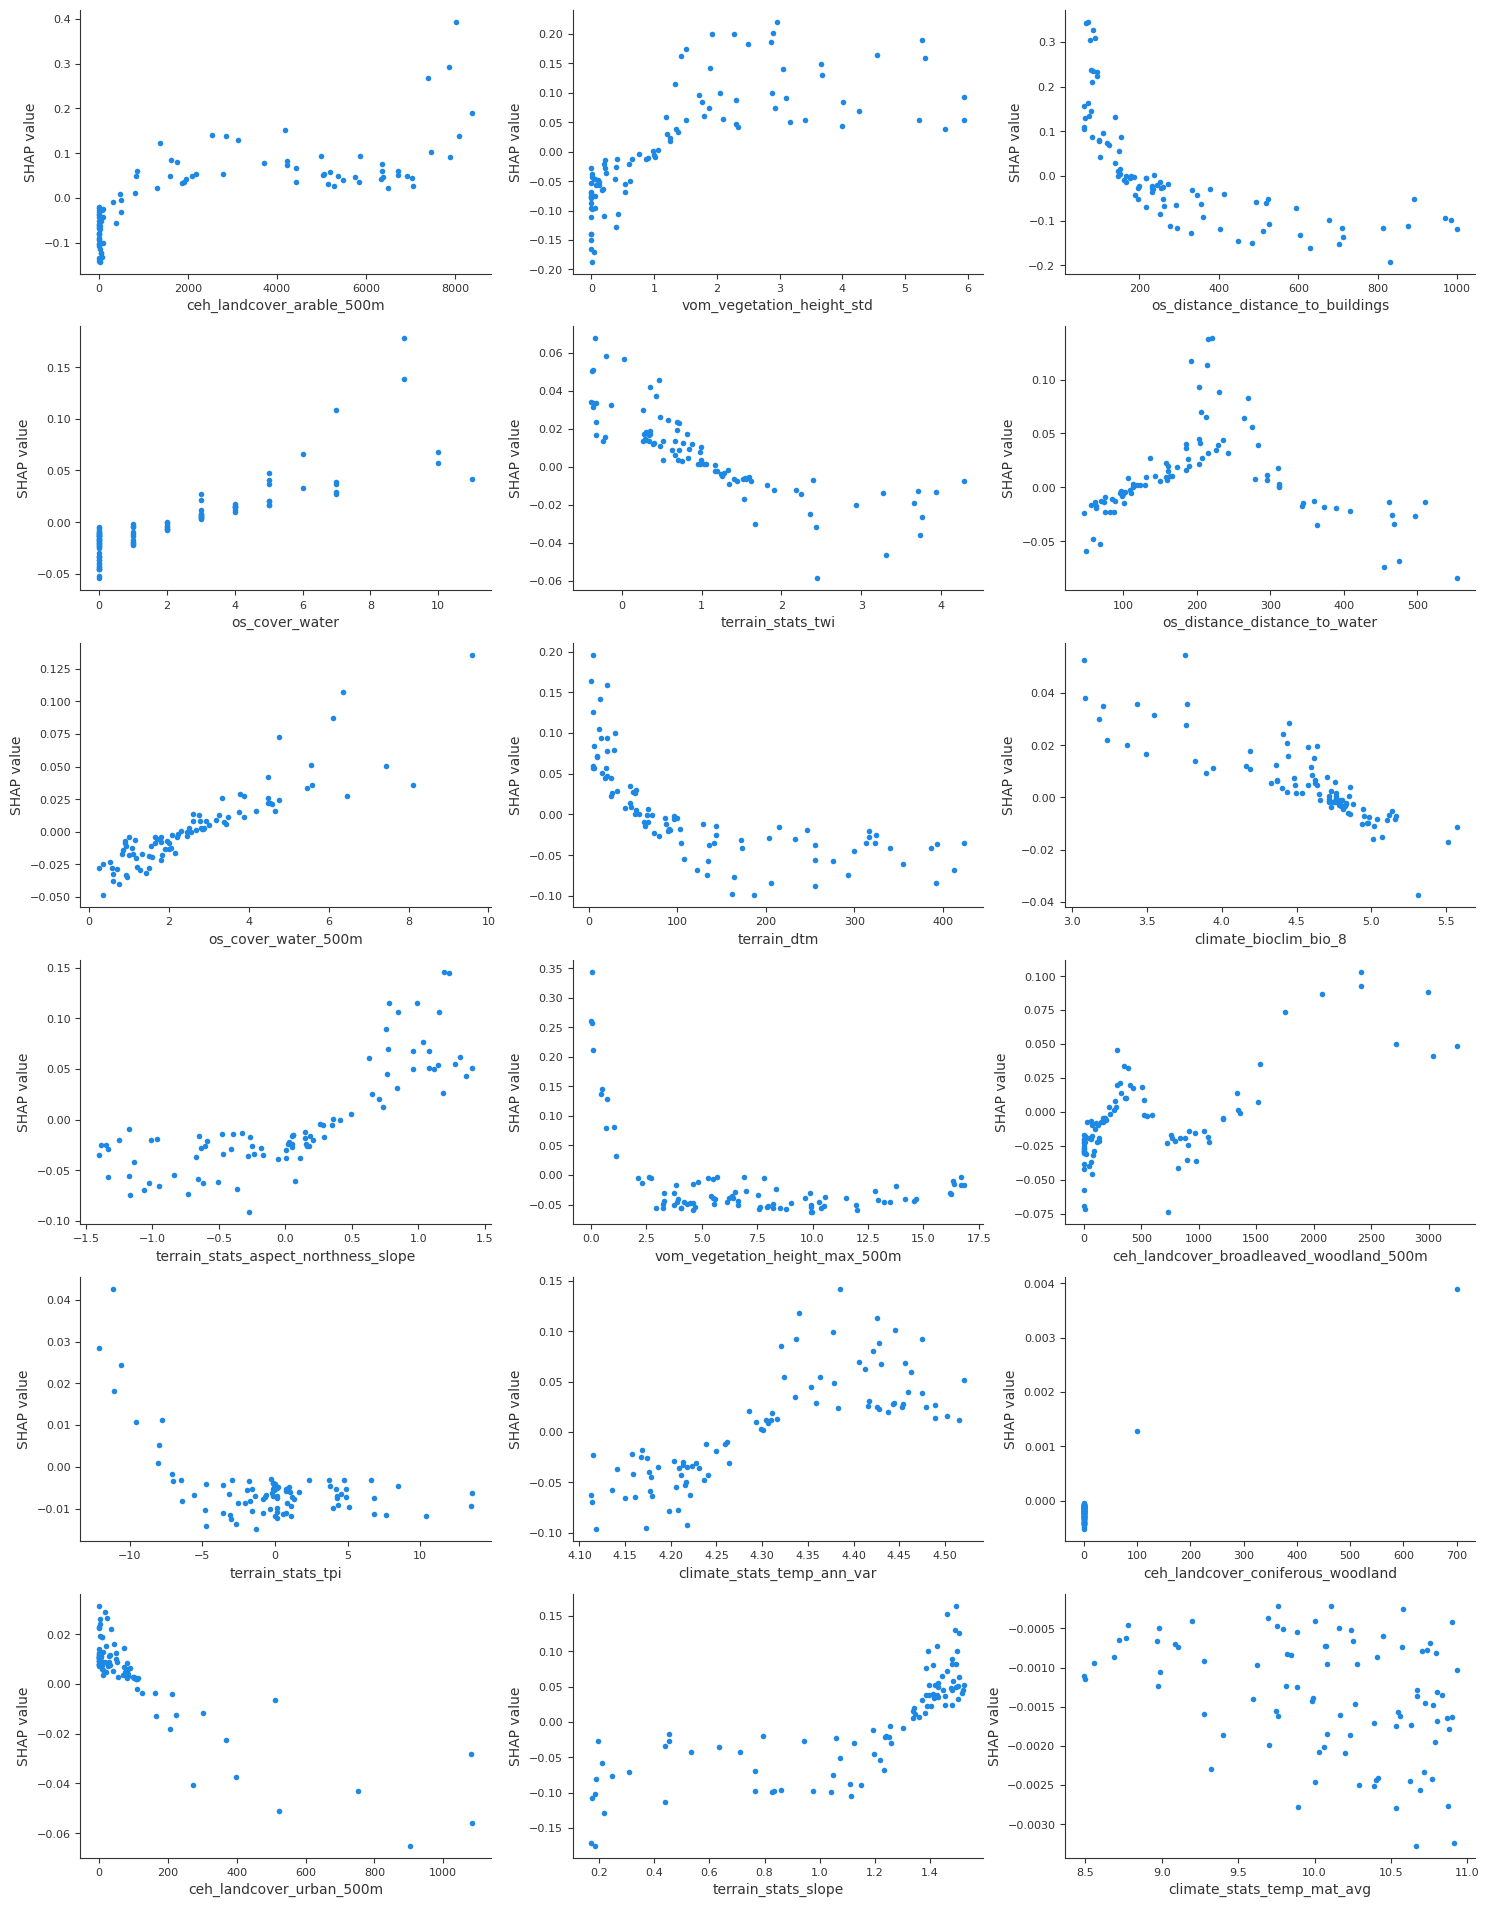

In [161]:
import numpy as np
import shap
import matplotlib.pyplot as plt


def plot_filtered_shap_dependence(
    feature_name,
    X_df,
    shap_values,
    p_low=1,
    p_high=99,
    interaction_index=None,
    fig=None,
    ax=None,
    figsize=(6, 4),
):
    """
    SHAP dependence plot filtered to percentile range, with support for
    passing in existing fig/ax so multiple plots can be placed in a panel.

    Parameters
    ----------
    feature_name : str
        Feature to plot.
    X_df : pandas.DataFrame
        Input features for the SHAP values.
    shap_values : shap.Explanation
        SHAP values aligned with X_df.
    p_low, p_high : int|float
        Percentile bounds for trimming the feature range.
    interaction_index : str|int|None
        Feature used for colour (None = same feature).
    fig, ax : matplotlib Figure/Axes or None
        If provided, SHAP will draw into this axis.
    figsize : tuple
        Only used if fig/ax are not provided.

    Returns
    -------
    fig, ax : Figure and Axes
    """

    # Compute percentile bounds
    low, high = np.percentile(X_df[feature_name], [p_low, p_high])

    # Filter rows to percentile limits
    mask = (X_df[feature_name] >= low) & (X_df[feature_name] <= high)
    X_filtered = X_df.loc[mask]
    shap_filtered = shap_values.values[mask, :]

    # Create fig/ax only if not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        # If ax provided but fig not, use ax.figure
        if fig is None:
            fig = ax.figure

    # Draw SHAP plot on this axis
    shap.dependence_plot(
        feature_name,
        shap_filtered,
        X_filtered,
        interaction_index=interaction_index,
        ax=ax,
        show=False,
    )

    return fig, ax


num_cols = 3
num_rows = int(np.ceil(len(model_features) / num_cols))

width = 6
height = 4

fig, axs = plt.subplots(
    num_rows, num_cols, figsize=(width * num_cols, height * num_rows)
)

for idx, row in variable_scores.iterrows():
    if idx >= num_rows * num_cols:
        break
    plt_row = idx // num_cols
    plt_col = idx % num_cols
    fig, _ = plot_filtered_shap_dependence(
        row["variable"],
        X_explain,
        shap_values,
        p_low=5,
        p_high=95,
        fig=fig,
        ax=axs[plt_row, plt_col],
    )
    # name y axis "shap value"
    axs[plt_row, plt_col].set_ylabel("SHAP value")
    axs[plt_row, plt_col].set_xlabel(row["variable"])
    # reduce tick size
    axs[plt_row, plt_col].tick_params(axis="both", which="major", labelsize=8)
    axs[plt_row, plt_col].tick_params(axis="both", which="minor", labelsize=8)
    # reduce text size
    # x axis
    axs[plt_row, plt_col].xaxis.label.set_size(10)
    # y axis
    axs[plt_row, plt_col].yaxis.label.set_size(10)
    # title
    axs[plt_row, plt_col].title.set_size(10)


fig.show()


In [167]:
latin_name
activity_type


<ActivityType.IN_FLIGHT: 'In flight'>

In [163]:
variable_scores

,variable,score,score_abs
0,ceh_landcover_arable_500m,0.027289,0.027289
1,vom_vegetation_height_std,0.017908,0.017908
2,os_distance_distance_to_buildings,0.014223,0.014223
3,os_cover_water,0.013778,0.013778
4,terrain_stats_twi,0.007586,0.007586
5,os_distance_distance_to_water,0.005394,0.005394
6,os_cover_water_500m,0.004567,0.004567
7,terrain_dtm,0.004206,0.004206
8,climate_bioclim_bio_8,0.003688,0.003688
9,terrain_stats_aspect_northness_slope,0.003013,0.003013


In [164]:
# explain a single point

x, y = 401195, 475151

point_evs = evs_to_model.sel(x=[x], y=[y], method="nearest").to_dataframe()

point_features = point_evs[model_features]

point_shap_values = explainer.shap_values(point_features)
point_shap_df = pd.DataFrame(
    data={
        "variable": model_features,
        "input_value": point_features.values[0],
        "shap_score": point_shap_values[0],
    }
).sort_values(by="shap_score", ascending=False)


point_shap_df


,variable,input_value,shap_score
14,vom_vegetation_height_max_500m,0.000000,0.267459
5,terrain_stats_slope,1.512204,0.057429
4,climate_bioclim_bio_8,2.625826,0.040017
8,os_cover_water,4.000000,0.016091
16,os_cover_water_500m,3.880000,0.010775
17,ceh_landcover_urban_500m,0.000000,0.010111
10,ceh_landcover_coniferous_woodland,0.000000,-0.000107
2,climate_stats_temp_mat_avg,8.003499,-0.001154
7,terrain_stats_tpi,9.566437,-0.005245
11,os_distance_distance_to_water,91.931587,-0.005846


In [165]:
import leafmap

m = leafmap.Map()
m.zoom_to_gdf(boundary_4326)
m.add_basemap("HYBRID")
m.add_raster(
    str(predictions_masked),
    layer_name="Predictions",
    cmap="viridis",
    nodata=np.nan,
    opacity=0.5,
)
m.add_gdf(
    species_presence,
    layer_name="Presence",
    point_style={"color": "orange", "weight": 1, "opacity": 0.7, "radius": 3},
)
m

Map(center=[53.925256000000005, -1.1879715000000002], controls=(ZoomControl(options=['position', 'zoom_in_text…